# Phase 0 — Tabular baseline figures (the line to beat)

Reads the versioned `results/baseline_tabular.json` produced by
`scripts/10_baseline_tabular.py` and renders the paper-facing figures for the
Phase 0 baseline. **All modelling logic lives in `src/embedbiomarker/`** — this
notebook only imports it, fits the fast head for risk stratification, and plots.

Figures:
1. Model comparison (Cox-PH / RSF / XGBoost-Cox), val & test C-index.
2. Risk-stratified Kaplan–Meier on the test fold (best model) + log-rank.
3. Per-cancer-type test C-index.
4. Treatment-history ablation — the immortal-time sanity check (count alone ≈ chance).
5. Between- vs within-cancer decomposition — how much of the pan-cancer C-index is
   just separating cancer types vs ranking risk *within* a type.

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve the repo root from any working dir (dev/, notebooks/, or root):
# walk up until we find pyproject.toml.
REPO = Path.cwd()
while not (REPO / 'pyproject.toml').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO / 'src'))

from embedbiomarker import survival as S
from embedbiomarker.baselines import build_model

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3})

data_cfg = S.load_config(REPO / 'config/data.yaml')
surv_cfg = S.load_config(REPO / 'config/survival.yaml')
bcfg = surv_cfg['baseline']
results = json.loads((REPO / 'results/baseline_tabular.json').read_text())
results['models'].keys()

dict_keys(['coxph', 'rsf', 'xgboost_cox'])

In [2]:
# Load table + frozen split, featurize (fit on TRAIN only — same path as the script).
df = S.load_table(REPO / 'data/interim/data_prompts.csv')
splits = S.load_splits(REPO / 'data/interim/splits.json')
frames = S.split_frames(df, splits)

# Split-integrity sanity check: one row per patient, folds fully disjoint.
ids = {p: set(frames[p]['PATIENT_ID']) for p in ('train', 'val', 'test')}
assert df['PATIENT_ID'].is_unique, 'table has >1 row per patient'
assert not (ids['train'] & ids['test']) and not (ids['train'] & ids['val']) \
    and not (ids['val'] & ids['test']), 'patient leaked across folds'
print('split OK — disjoint by PATIENT_ID:',
      {p: len(ids[p]) for p in ('train', 'val', 'test')})

fz = S.TabularFeaturizer(data_cfg, bcfg)
X = {p: (fz.fit_transform(frames[p]) if p == 'train' else fz.transform(frames[p]))
     for p in ('train', 'val', 'test')}
y = {p: S.make_target(frames[p], data_cfg) for p in ('train', 'val', 'test')}
print(f'{len(fz.columns_)} feature columns; test n={len(frames["test"])}')

split OK — disjoint by PATIENT_ID: {'train': 19022, 'val': 2378, 'test': 2377}


100 feature columns; test n=2377


## Fig 1 — Model comparison (C-index)

,val,test
xgboost_cox,0.7477,0.7549
coxph,0.7154,0.7306
rsf,0.6965,0.7040


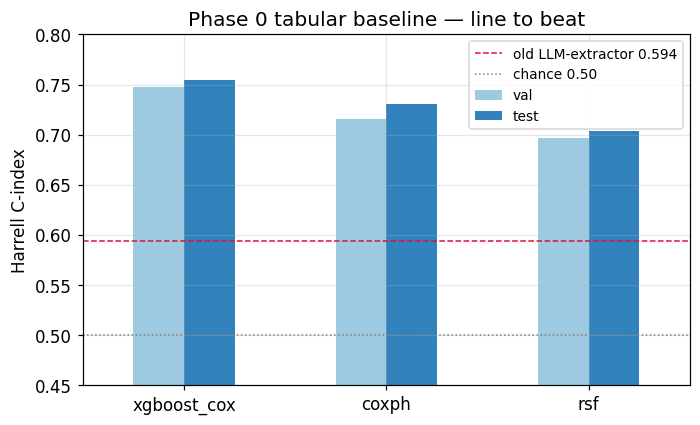

In [3]:
tbl = pd.DataFrame({name: r['c_index'] for name, r in results['models'].items()}).T
tbl = tbl[['val', 'test']].sort_values('test', ascending=False)
display(tbl.style.format('{:.4f}').background_gradient(cmap='Greens', axis=None))

ax = tbl.plot.bar(rot=0, figsize=(6.5, 4), color=['#9ecae1', '#3182bd'])
ax.axhline(0.594, ls='--', color='crimson', lw=1, label='old LLM-extractor 0.594')
ax.axhline(0.5, ls=':', color='gray', lw=1, label='chance 0.50')
ax.set_ylabel('Harrell C-index'); ax.set_ylim(0.45, 0.8)
ax.set_title('Phase 0 tabular baseline — line to beat'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

The tabular baseline (≈0.73–0.75) already **exceeds the old LLM-extractor's 0.594**.
That is the honest bar: embeddings (Phase 1) must beat the *tabular* number to justify the thesis.

## Fig 2 — Risk-stratified Kaplan–Meier (test fold, best model)

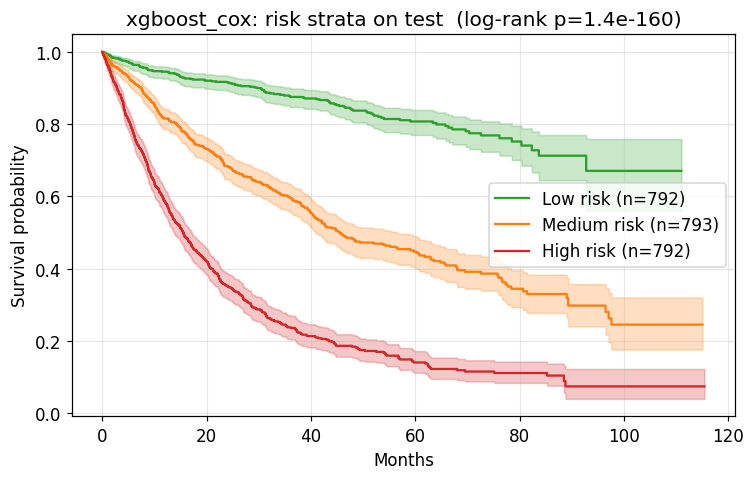

In [4]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

best_name = max(results['models'], key=lambda k: results['models'][k]['c_index']['test'])
best = build_model(best_name, bcfg).fit(X['train'], y['train'])
risk_test = best.predict_risk(X['test'])

# Tertiles of predicted risk -> Low / Medium / High groups.
groups = pd.qcut(risk_test, 3, labels=['Low risk', 'Medium risk', 'High risk'])
ty = y['test']

fig, ax = plt.subplots(figsize=(7, 4.5))
kmf = KaplanMeierFitter()
for g, color in zip(['Low risk', 'Medium risk', 'High risk'], ['#2ca02c', '#ff7f0e', '#d62728']):
    m = groups == g
    kmf.fit(ty['time'][m], ty['event'][m], label=f'{g} (n={m.sum()})')
    kmf.plot_survival_function(ax=ax, ci_show=True, color=color)

lr = multivariate_logrank_test(ty['time'], groups, ty['event'])
ax.set_xlabel('Months'); ax.set_ylabel('Survival probability')
ax.set_title(f'{best_name}: risk strata on test  (log-rank p={lr.p_value:.1e})')
plt.tight_layout(); plt.show()

## Fig 3 — Per-cancer-type test C-index

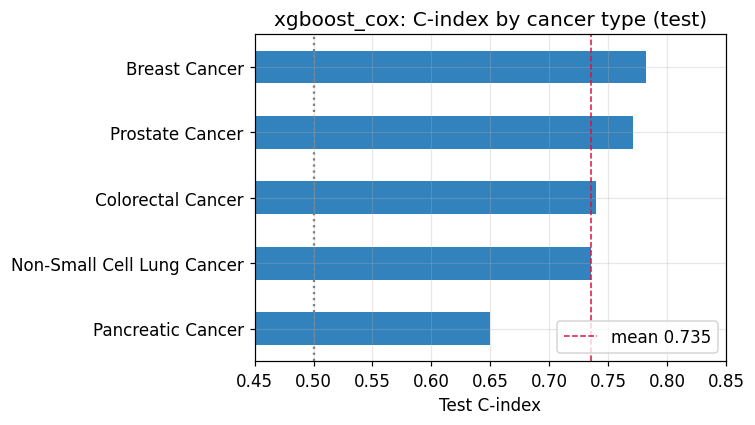

In [5]:
per = pd.Series(results['models'][best_name]['c_index_per_cancer_test']).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
per.plot.barh(ax=ax, color='#3182bd')
ax.axvline(0.5, ls=':', color='gray'); ax.axvline(per.mean(), ls='--', color='crimson', lw=1,
           label=f'mean {per.mean():.3f}')
ax.set_xlabel('Test C-index'); ax.set_xlim(0.45, 0.85)
ax.set_title(f'{best_name}: C-index by cancer type (test)'); ax.legend()
plt.tight_layout(); plt.show()

## Fig 4 — Treatment-history ablation (immortal-time sanity check)

`TREATMENT_HISTORY` is **post-baseline** (ordered agents with repeats). If the
*count* of treatments were just a proxy for time-alive, count alone would already
give a high C-index. It does **not** (≈ chance), so the treatment signal comes from
*which* agents (tumour biology / line), not from immortal-time leakage.

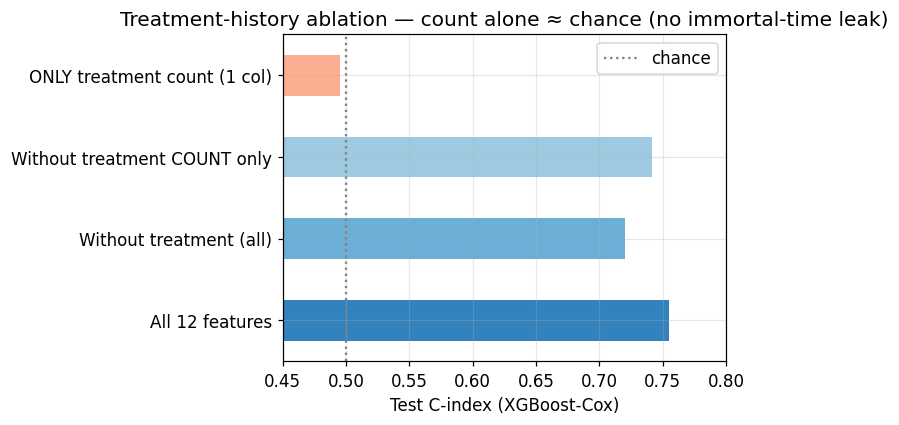

All 12 features                 0.7549
Without treatment (all)         0.7205
Without treatment COUNT only    0.7413
ONLY treatment count (1 col)    0.4950
dtype: float64

In [6]:
def score(cols):
    m = build_model('xgboost_cox', bcfg).fit(X['train'][cols], y['train'])
    return S.concordance(y['test'], m.predict_risk(X['test'][cols]))

allc = list(X['train'].columns)
tx = [c for c in allc if c.startswith('TREATMENT_HISTORY')]
abl = {
    'All 12 features': score(allc),
    'Without treatment (all)': score([c for c in allc if c not in tx]),
    'Without treatment COUNT only': score([c for c in allc if c != 'TREATMENT_HISTORY__count']),
    'ONLY treatment count (1 col)': score(['TREATMENT_HISTORY__count']),
}
abl = pd.Series(abl)
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#3182bd', '#6baed6', '#9ecae1', '#fcae91']
abl.plot.barh(ax=ax, color=colors)
ax.axvline(0.5, ls=':', color='gray', label='chance')
ax.set_xlabel('Test C-index (XGBoost-Cox)'); ax.set_xlim(0.45, 0.8)
ax.set_title('Treatment-history ablation — count alone ≈ chance (no immortal-time leak)')
ax.legend(); plt.tight_layout(); plt.show()
abl.round(4)

## Fig 5 — Between- vs within-cancer decomposition

Is the pan-cancer ≈0.75 mostly "easy" separation between cancer types, or real
within-cancer prognostication? `CANCER_TYPE` is **not** one of the 12 features —
but the model can infer it from HER2 / mutations / treatment regimens, and cancers
have very different baseline survival. We compare:

* **Pan-cancer** — full model, all test pairs.
* **Within-cancer (mean)** — the same model scored only on same-cancer pairs (the
  honest, harder task).
* **Cancer-type only** — a model whose *only* feature is the 5 cancer-type dummies
  (the between-cancer "free" ceiling).

If within-cancer ≈ pan-cancer, the signal is genuine, not a tumour-sorting artefact.

,cancer,n,events,within_C
3,Pancreatic Cancer,294,204,0.6494
2,Non-Small Cell Lung Cancer,742,381,0.7349
1,Colorectal Cancer,548,218,0.7399
4,Prostate Cancer,281,95,0.7707
0,Breast Cancer,512,192,0.7821


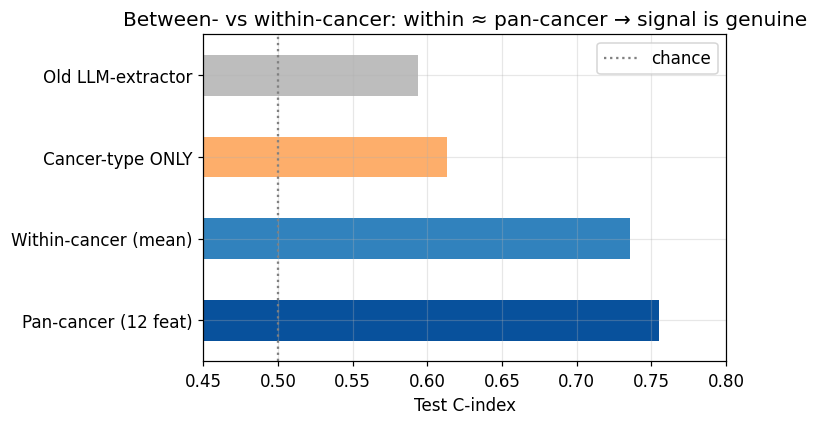

Pan-cancer (12 feat)    0.7549
Within-cancer (mean)    0.7354
Cancer-type ONLY        0.6129
Old LLM-extractor       0.5940
dtype: float64

In [7]:
# Full-model risk on test (reuse the best model fitted above).
pan = S.concordance(y['test'], risk_test)

# Within-cancer C-index: restrict scoring to same-cancer pairs, per type.
test_df = frames['test']
rows = []
for ct, idx in test_df.groupby('CANCER_TYPE').groups.items():
    pos = test_df.index.get_indexer(idx)
    suby = S.make_target(test_df.loc[idx], data_cfg)
    if int(suby['event'].sum()) >= 5:
        rows.append((ct, len(idx), int(suby['event'].sum()),
                     S.concordance(suby, risk_test[pos])))
within = pd.DataFrame(rows, columns=['cancer', 'n', 'events', 'within_C']).sort_values('within_C')

# Cancer-type-only survival model (between-cancer ceiling).
ct_tr = pd.get_dummies(frames['train']['CANCER_TYPE']).astype(float)
ct_te = pd.get_dummies(frames['test']['CANCER_TYPE']).astype(float).reindex(
    columns=ct_tr.columns, fill_value=0)
ct_only = S.concordance(
    y['test'], build_model('xgboost_cox', bcfg).fit(ct_tr, y['train']).predict_risk(ct_te))

display(within.round(4))
summary = pd.Series({
    'Pan-cancer (12 feat)': pan,
    'Within-cancer (mean)': within['within_C'].mean(),
    'Cancer-type ONLY': ct_only,
    'Old LLM-extractor': 0.594,
})
fig, ax = plt.subplots(figsize=(7, 4))
summary.plot.barh(ax=ax, color=['#08519c', '#3182bd', '#fdae6b', '#bdbdbd'])
ax.axvline(0.5, ls=':', color='gray', label='chance')
ax.set_xlabel('Test C-index'); ax.set_xlim(0.45, 0.8)
ax.set_title('Between- vs within-cancer: within ≈ pan-cancer → signal is genuine')
ax.legend(); plt.tight_layout(); plt.show()
summary.round(4)